In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost shap tldextract joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 4.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.parse import urlparse
import tldextract

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import shap
import joblib

In [3]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("malicious_phish.csv")
df.head()

Saving malicious_phish.csv to malicious_phish.csv


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [4]:
print(df.shape)

df.info()

df['type'].value_counts()

(651191, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     651191 non-null  object
 1   type    651191 non-null  object
dtypes: object(2)
memory usage: 9.9+ MB


,count
type,
benign,428103
defacement,96457
phishing,94111
malware,32520


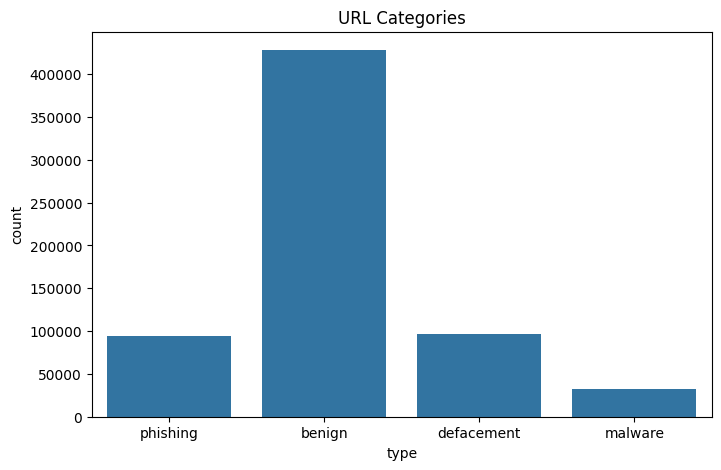

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['type'])

plt.title("URL Categories")
plt.show()

In [6]:
df['label'] = df['type'].apply(
    lambda x: 0 if x=="benign" else 1
)

df[['type','label']].head()

,type,label
0,phishing,1
1,benign,0
2,benign,0
3,defacement,1
4,defacement,1


In [7]:
def extract_features(url):

    features = {}

    features['url_length'] = len(url)

    features['num_dots'] = url.count('.')

    features['num_hyphens'] = url.count('-')

    features['num_slashes'] = url.count('/')

    features['num_digits'] = sum(c.isdigit() for c in url)

    features['num_special'] = len(
        re.findall(r'[@#$%^&*()+=]', url)
    )

    features['has_https'] = int("https" in url)

    features['has_ip'] = int(
        bool(re.search(r'\d+\.\d+\.\d+\.\d+', url))
    )

    ext = tldextract.extract(url)

    features['subdomain_length'] = len(ext.subdomain)

    suspicious_words = [
        'login',
        'verify',
        'secure',
        'update',
        'bank',
        'paypal',
        'signin'
    ]

    features['suspicious_keywords'] = sum(
        word in url.lower()
        for word in suspicious_words
    )

    return features

In [8]:
feature_df = pd.DataFrame(
    df['url'].apply(extract_features).tolist()
)

feature_df.head()

,url_length,num_dots,num_hyphens,num_slashes,num_digits,num_special,has_https,has_ip,subdomain_length,suspicious_keywords
0,16,2,1,0,0,0,0,0,0,0
1,35,2,0,2,1,0,0,0,0,0
2,31,2,0,3,1,0,0,0,0,0
3,88,3,1,3,7,7,0,0,3,0
4,235,2,1,3,22,5,0,0,0,0


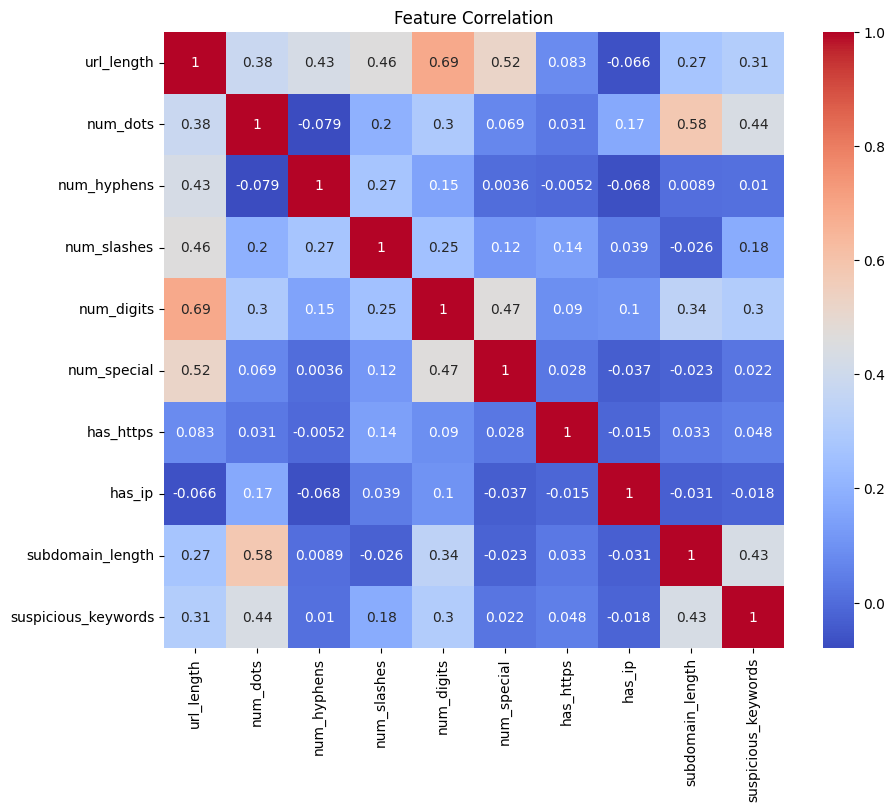

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(
    feature_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation")
plt.show()

In [10]:
X = feature_df

y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [12]:
pred = rf.predict(X_test)

acc = accuracy_score(y_test,pred)

print("Accuracy:",acc)

print(
    classification_report(
        y_test,
        pred
    )
)

Accuracy: 0.9427130122313593
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     85621
           1       0.93      0.91      0.92     44618

    accuracy                           0.94    130239
   macro avg       0.94      0.93      0.94    130239
weighted avg       0.94      0.94      0.94    130239



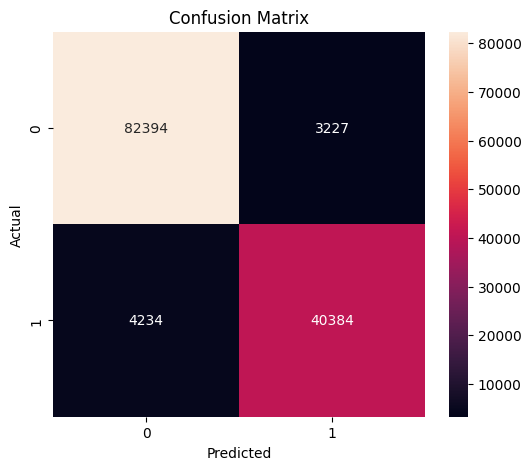

In [13]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

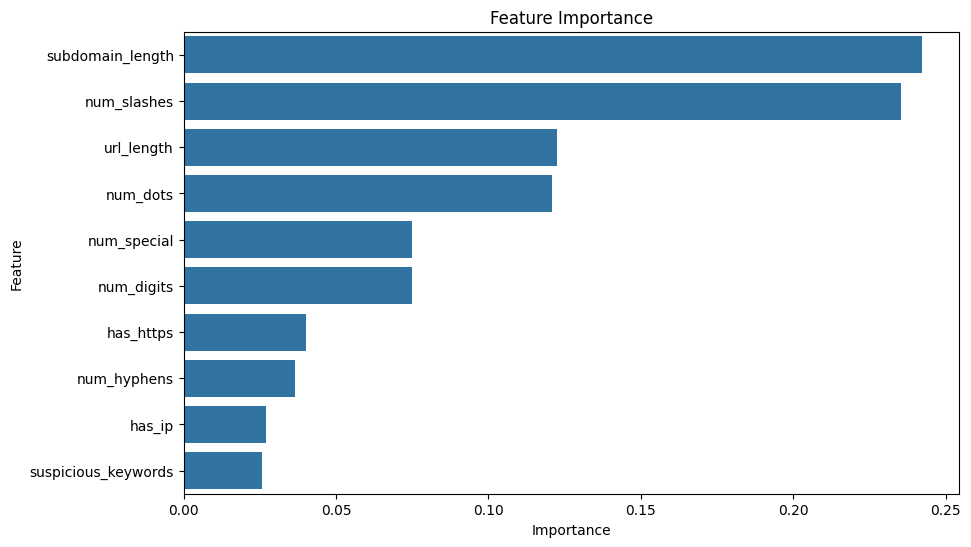

In [14]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

In [15]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [16]:
rf_pred = rf.predict(X_test)

xgb_pred = xgb.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

comparison = pd.DataFrame({
    'Model':['Random Forest','XGBoost'],
    'Accuracy':[rf_acc,xgb_acc]
})

comparison

,Model,Accuracy
0,Random Forest,0.942713
1,XGBoost,0.929092


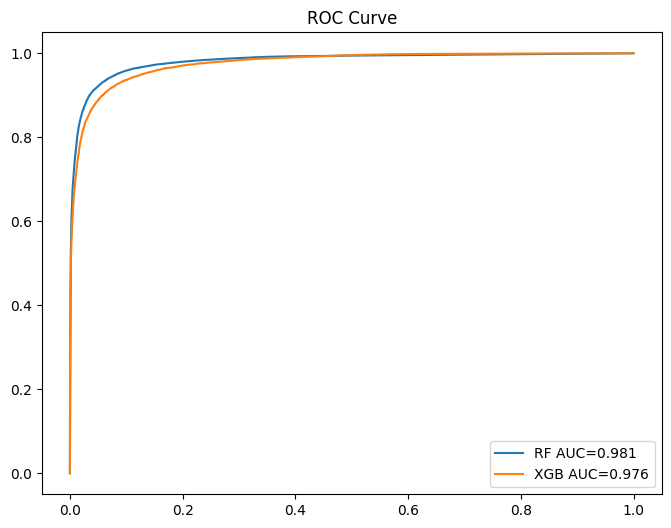

In [17]:
rf_prob = rf.predict_proba(X_test)[:,1]

xgb_prob = xgb.predict_proba(X_test)[:,1]

rf_fpr,rf_tpr,_ = roc_curve(
    y_test,
    rf_prob
)

xgb_fpr,xgb_tpr,_ = roc_curve(
    y_test,
    xgb_prob
)

rf_auc = auc(
    rf_fpr,
    rf_tpr
)

xgb_auc = auc(
    xgb_fpr,
    xgb_tpr
)

plt.figure(figsize=(8,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'RF AUC={rf_auc:.3f}'
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f'XGB AUC={xgb_auc:.3f}'
)

plt.legend()

plt.title("ROC Curve")

plt.show()

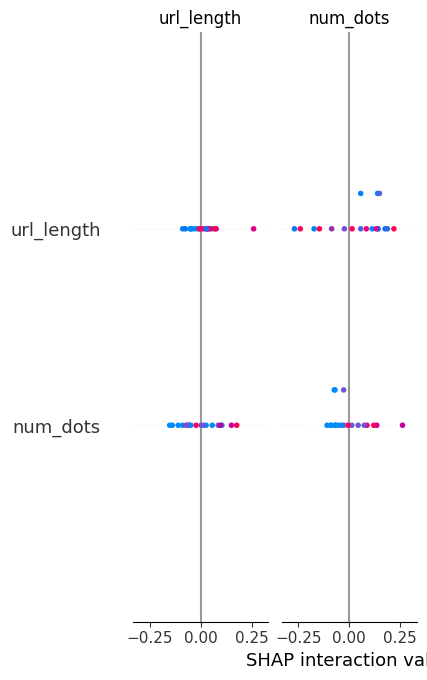

In [18]:
import shap

sample_data = X_test.sample(20, random_state=42)

explainer = shap.TreeExplainer(
    rf,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(sample_data)

shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

In [19]:
joblib.dump(
    rf,
    "cybershield_model.pkl"
)

print("Model Saved")

Model Saved


In [38]:
url = input("Enter URL: ")

sample = pd.DataFrame(
    [extract_features(url)]
)

prediction = rf.predict(sample)[0]

if prediction == 1:
    print("⚠️ Malicious URL")
else:
    print("✅ Safe URL")

Enter URL: http://example.com
✅ Safe URL


In [22]:
from sklearn.metrics import accuracy_score

pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9427130122313593


In [23]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96     85621
           1       0.93      0.91      0.92     44618

    accuracy                           0.94    130239
   macro avg       0.94      0.93      0.94    130239
weighted avg       0.94      0.94      0.94    130239

